In [1]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [2]:
!pip install duckdb

In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# データベースとの接続
con = duckdb.connect()

In [6]:
exchange = pd.read_csv("/content/drive/MyDrive/Data/japan-inbound-tourism-sql-analysis/exchange_rate_monthly.csv", encoding="shift-jis")
visitors = pd.read_csv("/content/drive/MyDrive/Data/japan-inbound-tourism-sql-analysis/japan_inbound_visitors_monthly.csv")
spending = pd.read_csv("/content/drive/MyDrive/Data/japan-inbound-tourism-sql-analysis/tourism_spending.csv")

display(exchange.head())
display(visitors.head())
display(spending.head())

,データコード,FM08'FXERM07,FM09'FX180110002
0,系列名称,東京市場 ドル・円 スポット 17時時点/月中平均,実質実効為替レート指数
1,1980/01,237.73,101.42
2,1980/02,244.07,98.68
3,1980/03,248.61,98.21
4,1980/04,251.45,98.8


,Country/Area,Month (abbr),Year,Visitor Arrivals,Growth Rate(%)
0,Afghanistan,Jan.,2019,263,NaN
1,Afghanistan,Feb.,2019,205,NaN
2,Afghanistan,Mar.,2019,245,NaN
3,Afghanistan,Apr.,2019,244,NaN
4,Afghanistan,May,2019,172,NaN


,year,spending_amount_oku,spending_per_person_man
0,2015,34771,17.6
1,2016,37476,15.6
2,2017,44162,15.4
3,2018,45189,15.3
4,2019,48135,15.9


In [7]:
print(exchange.columns)
print(visitors.columns)
print(spending.columns)

Index(['データコード', 'FM08'FXERM07', 'FM09'FX180110002'], dtype='object')
Index(['Country/Area', 'Month (abbr)', 'Year', 'Visitor Arrivals',
       'Growth Rate(%)'],
      dtype='object')
Index(['year', 'spending_amount_oku', 'spending_per_person_man'], dtype='object')


In [8]:
# --- exchange の列名を変更 ---
exchange = exchange.rename(columns={
    "データコード": "date",
    "FM08'FXERM07": "usd_jpy",
    "FM09'FX180110002": "reer"
})

# --- visitors の列名を変更 ---
visitors = visitors.rename(columns={
    "Country/Area": "country_area",
    "Month (abbr)": "month_abbr",
    "Year": "year",
    "Visitor Arrivals": "visitor_arrivals",
    "Growth Rate(%)": "growth_rate"
})

# spending はこのまま

In [10]:
print(exchange.dtypes)
print(visitors.dtypes)
print(spending.dtypes)

date       object
usd_jpy    object
reer       object
dtype: object
country_area        object
month_abbr          object
year                 int64
visitor_arrivals    object
growth_rate         object
dtype: object
year                         int64
spending_amount_oku          int64
spending_per_person_man    float64
dtype: object


In [14]:
# --- exchange ---

# 先頭の説明行を削除
exchange = exchange.iloc[1:].copy()

# date を datetime に
exchange["date"] = pd.to_datetime(exchange["date"], format="%Y/%m")

# 数値に変換
exchange["usd_jpy"] = pd.to_numeric(exchange["usd_jpy"], errors="coerce")
exchange["reer"] = pd.to_numeric(exchange["reer"], errors="coerce")

# 年と月を作る（超重要）
exchange["year"] = exchange["date"].dt.year
exchange["month"] = exchange["date"].dt.month

In [16]:
# --- visitors ---

# カンマ除去して数値化
visitors["visitor_arrivals"] = pd.to_numeric(
    visitors["visitor_arrivals"].astype(str).str.replace(",", ""),
    errors="coerce"
)

# 月を数字に変換
month_map = {
    "Jan.":1, "Feb.":2, "Mar.":3, "Apr.":4,
    "May":5, "Jun.":6, "Jul.":7, "Aug.":8,
    "Sep.":9, "Oct.":10, "Nov.":11, "Dec.":12
}

visitors["month"] = visitors["month_abbr"].map(month_map)

In [18]:
print(exchange.dtypes)
print(visitors.dtypes)

date       datetime64[ns]
usd_jpy           float64
reer              float64
year                int32
month               int32
dtype: object
country_area         object
month_abbr           object
year                  int64
visitor_arrivals    float64
growth_rate          object
month                 int64
dtype: object


In [19]:
# 月次の総訪日客数
visitors_total = (
    visitors.groupby(["year", "month"], as_index=False)["visitor_arrivals"]
    .sum()
    .rename(columns={"visitor_arrivals": "total_visitors"})
)

visitors_total.head(12)

,year,month,total_visitors
0,2019,1,2689339.0
1,2019,2,2604322.0
2,2019,3,2760136.0
3,2019,4,2926685.0
4,2019,5,2773091.0
5,2019,6,2880041.0
6,2019,7,2991189.0
7,2019,8,2520134.0
8,2019,9,2272883.0
9,2019,10,2496568.0


In [20]:
print(visitors_total["year"].min(), visitors_total["year"].max())
print(exchange["year"].min(), exchange["year"].max())

2019 2025
1980 2025


In [22]:
# 訪日客に合わせる（これが自然）
exchange_filtered = exchange[
    (exchange["year"] >= visitors_total["year"].min()) &
    (exchange["year"] <= visitors_total["year"].max())
]

In [24]:
print(exchange_filtered["year"].min(), exchange_filtered["year"].max())

2019 2025


In [29]:
# 結合
df_merged = pd.merge(
    visitors_total,
    exchange_filtered,
    on=["year", "month"],
    how="left"
)

df_merged.head(12)

,year,month,total_visitors,date,usd_jpy,reer
0,2019,1,2689339.0,2019-01-01,108.97,99.19
1,2019,2,2604322.0,2019-02-01,110.36,96.92
2,2019,3,2760136.0,2019-03-01,111.22,96.21
3,2019,4,2926685.0,2019-04-01,111.63,96.00
4,2019,5,2773091.0,2019-05-01,109.76,98.51
5,2019,6,2880041.0,2019-06-01,108.07,99.79
6,2019,7,2991189.0,2019-07-01,108.23,99.33
7,2019,8,2520134.0,2019-08-01,106.34,102.87
8,2019,9,2272883.0,2019-09-01,107.40,101.64
9,2019,10,2496568.0,2019-10-01,108.12,100.47


In [35]:
print(df_merged.shape)
print(spending.shape)

# DataFrameをDuckDBに登録する
con.register("monthly_tourism_df", df_merged)
con.register("spending_df", spending)

# pandasのDataFrameをSQLの「テーブル」として使えるようにしている

(84, 6)
(10, 3)


In [36]:
# SQLで確認
con.execute("""
SELECT *
FROM monthly_tourism_df
LIMIT 12
""").fetchdf()

# SELECT * → 全列
# FROM monthly_tourism_df → このテーブルから
# LIMIT 12 → 最初の12行だけ
# .fetchdf() 👉 SQLの結果を pandasのDataFrameとして取得

,year,month,total_visitors,date,usd_jpy,reer
0,2019,1,2689339.0,2019-01-01,108.97,99.19
1,2019,2,2604322.0,2019-02-01,110.36,96.92
2,2019,3,2760136.0,2019-03-01,111.22,96.21
3,2019,4,2926685.0,2019-04-01,111.63,96.00
4,2019,5,2773091.0,2019-05-01,109.76,98.51
5,2019,6,2880041.0,2019-06-01,108.07,99.79
6,2019,7,2991189.0,2019-07-01,108.23,99.33
7,2019,8,2520134.0,2019-08-01,106.34,102.87
8,2019,9,2272883.0,2019-09-01,107.40,101.64
9,2019,10,2496568.0,2019-10-01,108.12,100.47


In [37]:
# 年次データ
query_yearly = """
SELECT
    year,
    SUM(total_visitors) AS yearly_visitors,
    AVG(usd_jpy) AS avg_usd_jpy,
    AVG(reer) AS avg_reer
FROM monthly_tourism_df
GROUP BY year
ORDER BY year
"""

In [42]:
# 月次データ → 年次データへのSQL集計
yearly_sql = con.execute(query_yearly).fetchdf()
yearly_sql

,year,yearly_visitors,avg_usd_jpy,avg_reer
0,2019,31882049.0,109.013333,99.055833
1,2020,4115828.0,106.780833,99.999167
2,2021,245862.0,109.781667,91.298333
3,2022,3832110.0,131.370833,78.757500
4,2023,25066350.0,140.507500,74.891667
5,2024,36870148.0,151.498333,70.845000
6,2025,39066046.0,149.647500,72.120833


In [45]:
query_with_spending = """
SELECT
    y.year,
    y.yearly_visitors,
    y.avg_usd_jpy,
    y.avg_reer,
    s.spending_amount_oku,
    s.spending_per_person_man
FROM (
    SELECT
        year,
        SUM(total_visitors) AS yearly_visitors,
        AVG(usd_jpy) AS avg_usd_jpy,
        AVG(reer) AS avg_reer
    FROM monthly_tourism_df
    GROUP BY year
) y
LEFT JOIN spending_df s
    ON y.year = s.year
ORDER BY y.year
"""

In [46]:
final_sql = con.execute(query_with_spending).fetchdf()
final_sql

,year,yearly_visitors,avg_usd_jpy,avg_reer,spending_amount_oku,spending_per_person_man
0,2019,31882049.0,109.013333,99.055833,48135,15.9
1,2020,4115828.0,106.780833,99.999167,7446,18.5
2,2021,245862.0,109.781667,91.298333,1208,NaN
3,2022,3832110.0,131.370833,78.757500,8987,23.5
4,2023,25066350.0,140.507500,74.891667,53065,21.3
5,2024,36870148.0,151.498333,70.845000,81257,22.7
6,2025,39066046.0,149.647500,72.120833,<NA>,NaN


In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 表示用に 2025 の欠損行は外す
plot_df = final_sql.dropna(subset=["spending_amount_oku", "spending_per_person_man"]).copy()

# 相関係数
corr_usd_visitors = plot_df["avg_usd_jpy"].corr(plot_df["yearly_visitors"])
corr_usd_spending = plot_df["avg_usd_jpy"].corr(plot_df["spending_per_person_man"])

print("Correlation: USD/JPY vs Yearly Visitors =", round(corr_usd_visitors, 3))
print("Correlation: USD/JPY vs Spending per Person =", round(corr_usd_spending, 3))

Correlation: USD/JPY vs Yearly Visitors = 0.426
Correlation: USD/JPY vs Spending per Person = 0.819


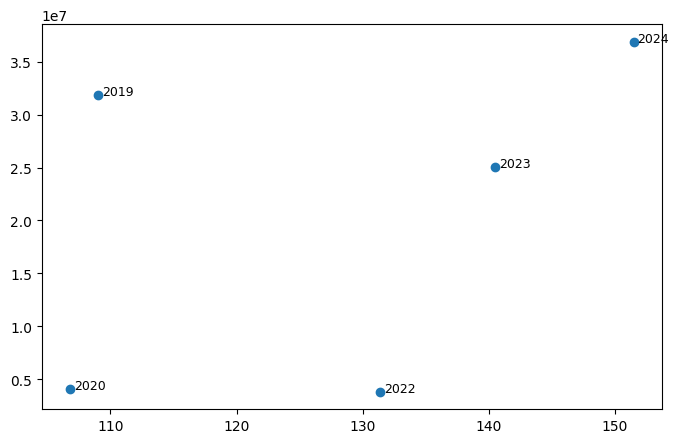

In [49]:
# ----------------------------
# 1. USD/JPY vs Yearly Visitors
# ----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(plot_df["avg_usd_jpy"], plot_df["yearly_visitors"])

for _, row in plot_df.iterrows():
    plt.text(row["avg_usd_jpy"] + 0.3, row["yearly_visitors"], str(int(row["year"])), fontsize=9)

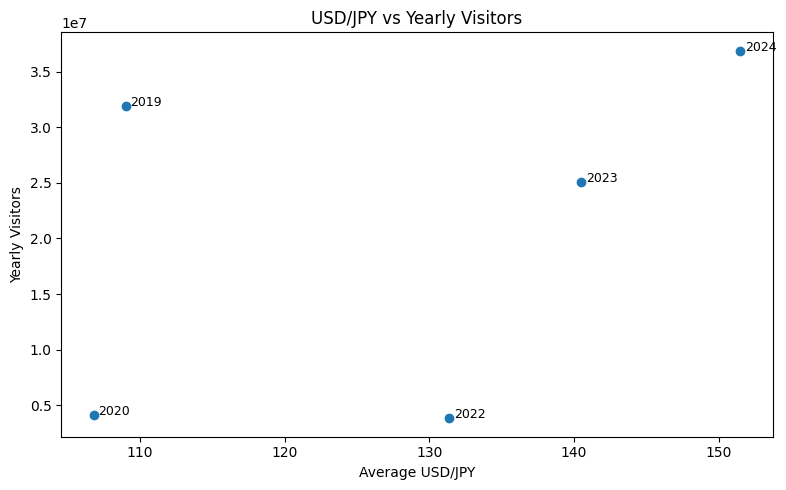

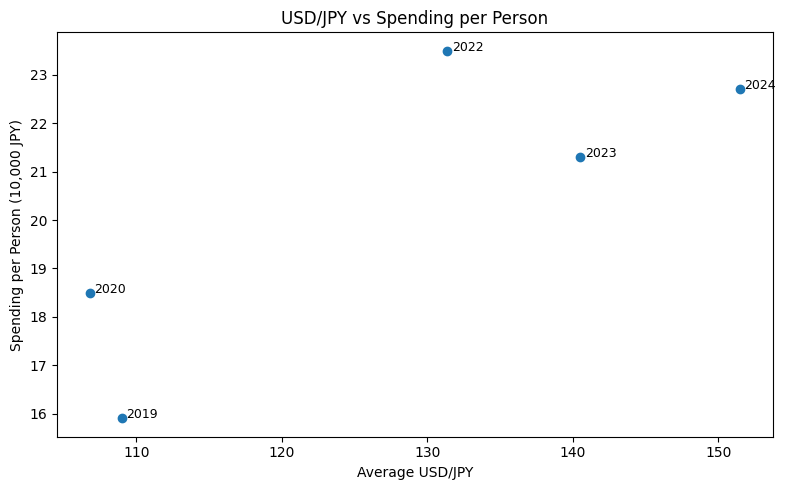

In [51]:
# Figure 1
plt.figure(figsize=(8, 5))
plt.scatter(plot_df["avg_usd_jpy"], plot_df["yearly_visitors"])
for _, row in plot_df.iterrows():
    plt.text(row["avg_usd_jpy"] + 0.3, row["yearly_visitors"], str(int(row["year"])), fontsize=9)
plt.title("USD/JPY vs Yearly Visitors")
plt.xlabel("Average USD/JPY")
plt.ylabel("Yearly Visitors")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Data/japan-inbound-tourism-sql-analysis/usd_jpy_vs_visitors.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2
plt.figure(figsize=(8, 5))
plt.scatter(plot_df["avg_usd_jpy"], plot_df["spending_per_person_man"])
for _, row in plot_df.iterrows():
    plt.text(row["avg_usd_jpy"] + 0.3, row["spending_per_person_man"], str(int(row["year"])), fontsize=9)
plt.title("USD/JPY vs Spending per Person")
plt.xlabel("Average USD/JPY")
plt.ylabel("Spending per Person (10,000 JPY)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Data/japan-inbound-tourism-sql-analysis/usd_jpy_vs_spending_per_person.png", dpi=300, bbox_inches="tight")
plt.show()